# 05 - Baseline modeling
## Obiettivo del notebook
Costruire primi modelli semplici per avere una baseline di confronto.

# 1. Caricamento dati e distinzione tra features categoriche/numeriche
Carichiamo i due file principali (values e labels) e separiamo le colonne in base al loro tipo

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
import os
warnings.filterwarnings('ignore')

if 'COLAB_GPU' in os.environ or 'GREETING' in os.environ:
    # Percorso per Colab
    base_path = '/content/'
else:
    # Percorso per locale (cartella relativa al notebook)
    base_path = 'data/raw/'

train_values = pd.read_csv(os.path.join(base_path, 'train_values.csv'))
train_labels = pd.read_csv(os.path.join(base_path, 'train_labels.csv'))

features = train_values.drop(columns=['building_id'])
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Preprocessing (da continuare a sviluppare in seguito)
Qui trasformiamo i dati grezzi in un formato "masticabile" dagli algoritmi.

* **One-Hot Encoding**: trasformiamo le variabili categoriche in numeri che i modelli possono elaborare.
Target Encoding Geografico (Risk Mapping)

* **Target Encoding**: sostituiamo gli ID geografici con statistiche calcolate sul target.                       
Risk Mean: Rappresenta il danno medio atteso per ogni zona (pericolosità locale).                
Risk Std: Misura l'eterogeneità del danno all'interno della stessa area.

* **Train-Test Split**: Dividiamo il dataset in due parti (80% training, 20% validation). Questo ci permette di testare il modello su dati che non ha mai visto, simulando la sfida finale.

* **Scaling**: questo è vitale per la Logistic Regression, che altrimenti darebbe troppa importanza alle variabili con numeri grandi.

*Nota: Per evitare il data leakage, le medie vengono calcolate solo sul set di training e poi mappate sul validation, riempiendo eventuali valori nuovi con la media globale.*


In [4]:
# 1. Preparazione base (senza building_id)
X = train_values.drop(columns=['building_id'])
y = train_labels['damage_grade']

# 2. Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Target Encoding Geografico
geo_cols = ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']

for col in geo_cols:
    # Creiamo un dataframe temporaneo di training per calcolare le medie
    temp_df = X_train[[col]].copy()
    temp_df['target'] = y_train

    # Calcolo medie e std solo dal TRAIN
    risk_map = temp_df.groupby(col)['target'].mean()
    std_map = temp_df.groupby(col)['target'].std()

    # Mappiamo su TRAIN
    X_train[f'{col}_risk_mean'] = X_train[col].map(risk_map)
    X_train[f'{col}_risk_std'] = X_train[col].map(std_map).fillna(0)

    # Mappiamo su VAL
    X_val[f'{col}_risk_mean'] = X_val[col].map(risk_map).fillna(y_train.mean())
    X_val[f'{col}_risk_std'] = X_val[col].map(std_map).fillna(0)

# 4. One-Hot Encoding delle altre categoriche
# Specifichiamo le colonne categoriche testuali (escludendo le geo già trattate)
categorical_text = X_train.select_dtypes(include=['object']).columns.tolist()

X_train = pd.get_dummies(X_train, columns=categorical_text)
X_val = pd.get_dummies(X_val, columns=categorical_text)

# Sincronizziamo le colonne (nel caso ci siano categorie nel train non presenti nel val)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

# 5. Pulizia colonne
cols_to_drop = geo_cols
X_train.drop(columns=cols_to_drop, inplace=True, errors='ignore')
X_val.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 6. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Pre-processing completato con Target Encoding!")

Pre-processing completato con Target Encoding!


# 3. Inizializzazione dei modelli

In [5]:
models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=25,       # Un po' più profondo, ma non infinito
        min_samples_leaf=5, # Evita che impari a memoria i singoli casi
        random_state=42,
        n_jobs=-1
    )
}

# 4. Training e Evaluation
Per ogni modello:

* Lo addestriamo sui dati di training

* Gli chiediamo di fare predizioni sui dati di validazione

* Calcoliamo la Micro-F1 Score, generiamo il Classification Report  e la Confusion Matrix


==================== DUMMY CLASSIFIER ====================
Micro-F1 Score: 0.5689

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      5025
           2       0.57      1.00      0.73     29652
           3       0.00      0.00      0.00     17444

    accuracy                           0.57     52121
   macro avg       0.19      0.33      0.24     52121
weighted avg       0.32      0.57      0.41     52121



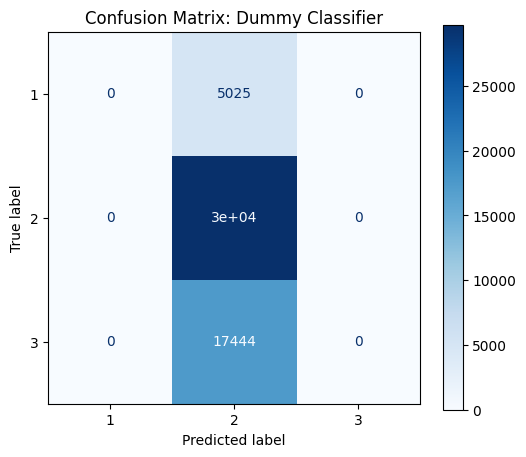


==================== LOGISTIC REGRESSION ====================
Micro-F1 Score: 0.7282

Classification Report:
              precision    recall  f1-score   support

           1       0.63      0.46      0.53      5025
           2       0.74      0.81      0.78     29652
           3       0.72      0.67      0.69     17444

    accuracy                           0.73     52121
   macro avg       0.70      0.65      0.67     52121
weighted avg       0.72      0.73      0.72     52121



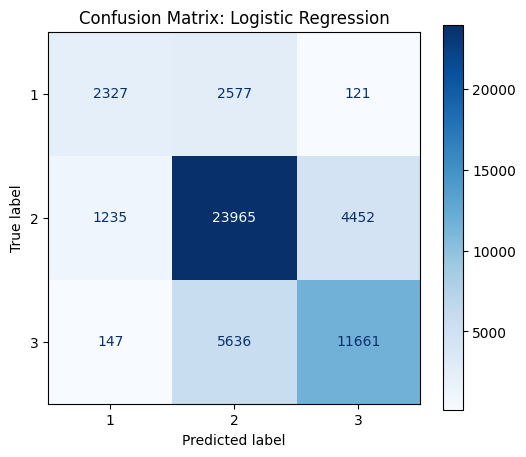


==================== DECISION TREE ====================
Micro-F1 Score: 0.7254

Classification Report:
              precision    recall  f1-score   support

           1       0.61      0.51      0.55      5025
           2       0.73      0.84      0.78     29652
           3       0.75      0.60      0.67     17444

    accuracy                           0.73     52121
   macro avg       0.70      0.65      0.67     52121
weighted avg       0.72      0.73      0.72     52121



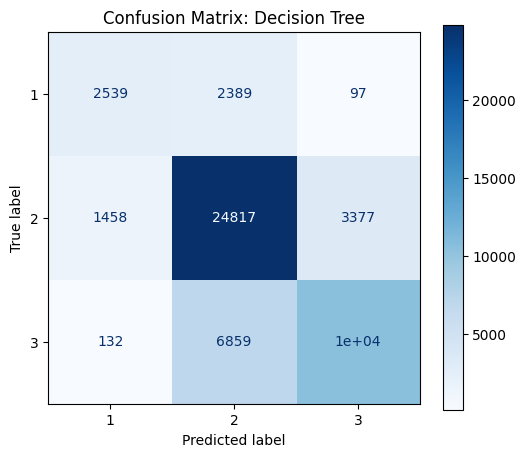


==================== RANDOM FOREST ====================
Micro-F1 Score: 0.7498

Classification Report:
              precision    recall  f1-score   support

           1       0.70      0.53      0.60      5025
           2       0.75      0.85      0.80     29652
           3       0.76      0.65      0.70     17444

    accuracy                           0.75     52121
   macro avg       0.74      0.68      0.70     52121
weighted avg       0.75      0.75      0.75     52121



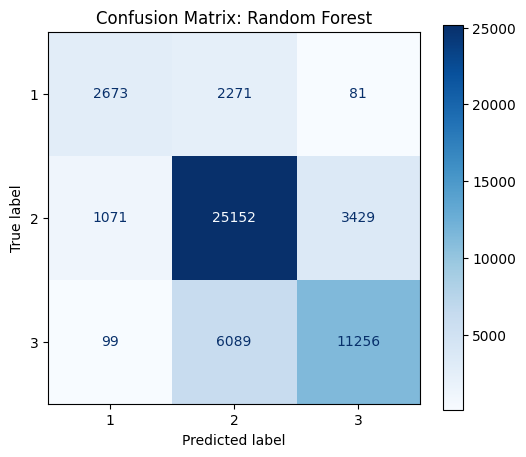

In [6]:
baseline_results = []

for name, model in models.items():
    print(f"\n{'='*20} {name.upper()} {'='*20}")

    # Usiamo i dati scalati solo per la Logistic Regression
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

    # 1. Micro-F1 Score
    score = f1_score(y_val, y_pred, average='micro')
    baseline_results.append({"Model": name, "Micro-F1": score})
    print(f"Micro-F1 Score: {score:.4f}")

    # 2. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    # 3. Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues', ax=ax)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

# 5. Tabella di comparazione finale

In [7]:
summary_df = pd.DataFrame(baseline_results).sort_values(by="Micro-F1", ascending=False)
print("\n" + "="*20 + " SUMMARY TABLE " + "="*20)
print(summary_df)


==================== SUMMARY TABLE ====================
                 Model  Micro-F1
3        Random Forest  0.749813
1  Logistic Regression  0.728171
2        Decision Tree  0.725408
0     Dummy Classifier  0.568907


# 6. Conclusioni
## 1. Il "Punto Zero": Dummy Classifier (0.5689)

* Il Dummy Classifier ci dice che se scommettessimo sempre sul Grado 2 (il più frequente), avremmo ragione nel 56.89% dei casi.

* Qualsiasi modello "serio" deve fare sensibilmente meglio di 0.57 per essere considerato utile.

## 2. Logistic Regression (0.7282)

* La Logistic Regression si dimostra subito molto efficace, raggiungendo uno score di 0.7282.

* Questo risultato suggerisce che l'integrazione del Target Encoding per i livelli geografici ha funzionato: il modello riesce a trasformare i dati sulla posizione in una probabilità di rischio lineare molto accurata.

* La Recall sul Grado 3 (0.67) indica che il modello è già in grado di identificare correttamente la maggior parte degli edifici distrutti.

## 3. Decision Tree (0.7254) e Random Forest (0.7498)

* Decision Tree: pur essendo un modello semplice, ottiene prestazioni quasi identiche alla Logistic Regression (0.7254), confermando che la struttura dei dati è ben predisposta per divisioni gerarchiche.

* Random Forest (miglior modello): con un Micro-F1 di 0.7498, è attualmente il nostro modello di riferimento.

* Riesce a gestire meglio degli altri la classe 2 (F1-score di 0.80), che è quella numericamente più complessa da separare.